In [3]:
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import pandas as pd
# Enable interactive backend
%matplotlib widget

In [9]:
# Load necessary files
pltfile = PltFileUtils('./cylinder.plt')
rstfile = UnkFileUtils('./cylinder.rst', extend=False) # read file at iteraton = 101

# Extract the side surface
side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=3)

# note : flag = 3 is the flag on the out of plane surface, the xy plane
# flag = 4 is the bottom plane and flag = 3 is the top plane

# Compute flow primitives 
rstfile._primitive()

In [12]:
# read jacobian.txt file (iteration = 101)
jacobian = pd.read_csv('jacobian.txt',delim_whitespace=True, header=None)
#print(jacobian.shape)   # Should print (3060, 26)
#print(jacobian.head())
J = jacobian.to_numpy()

print(J.shape)
# extract the column 1 to 25 of the J matrix
# reshape it to (number of data, row,col)
J = J[:,1:].reshape(-1,5,5, order= "F")
print(J)

(3060, 26)
[[[ 1.371740e-02  1.830140e-04 -4.311054e-04  6.761348e-05  1.057199e-03]
  [-1.995539e-02  2.251532e-02 -4.901895e-04  4.982791e-04  3.222069e-03]
  [ 8.695873e-03  6.246390e-04  2.792190e-02 -9.226804e-04 -1.157462e-03]
  [-1.214566e-03  3.126849e-04 -8.781998e-04  2.959840e-02  2.412706e-05]
  [-1.354859e-01  1.616423e-02 -1.973535e-02  3.415256e-03  5.274567e-02]]

 [[ 9.735395e-03  2.152269e-04 -5.591534e-04  8.751278e-06  8.202203e-04]
  [-1.442814e-02  1.710292e-02 -1.795440e-03  1.835554e-04  2.160826e-03]
  [ 9.792014e-03 -5.911975e-04  2.188143e-02  9.915171e-06 -1.023549e-03]
  [-2.863224e-04  1.600216e-04  1.477242e-05  2.079842e-02  2.611523e-06]
  [-9.746359e-02  1.550455e-02 -2.563091e-02  5.790409e-04  3.952014e-02]]

 [[ 6.681379e-03 -8.223703e-05  1.644772e-04 -3.885677e-05  7.107548e-04]
  [-8.755066e-03  1.296387e-02  2.185248e-03 -1.653595e-04  1.450891e-03]
  [ 2.742123e-03  1.928140e-03  1.437157e-02  3.404656e-04 -6.134985e-04]
  [ 3.679106e-04 -8.449

/tmp/ipykernel_131339/3330402085.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  jacobian = pd.read_csv('jacobian.txt',delim_whitespace=True, header=None)


In [5]:
# contructing triangulation 
# use some utilities from GrpFileUtils
tmp_grp = GrpFileUtils('tmp', 0, 
                       read=False,
                       coord=side_coords, 
                       nodes=side_nodes)
tmp_grp.root_nodemap = side_nodemap 

# setting x and y bounds for the data
x_upper = 15
x_lower = -4
y_upper = 4
y_lower = -4

# Filter points based on x and y coordinate bounds 
node_filter = (side_coords[:, 0] > x_lower) & (side_coords[:, 0] < x_upper) & (side_coords[:, 1] > y_lower) & (side_coords[:, 1] < y_upper )
tmp_grp.node_filter = node_filter

# Extract triangle nodemap
tri_nodemap = tmp_grp.get_tri_nodemap() 
# saving the x and y coordinates to grp_x and grp_y

grp_x = tmp_grp.coords[:, 0]
grp_y = tmp_grp.coords[:, 1]
# Construct a matplotlib Triangulation (defines our mesh for plotting)
tri = Triangulation(grp_x, grp_y, triangles=tri_nodemap)

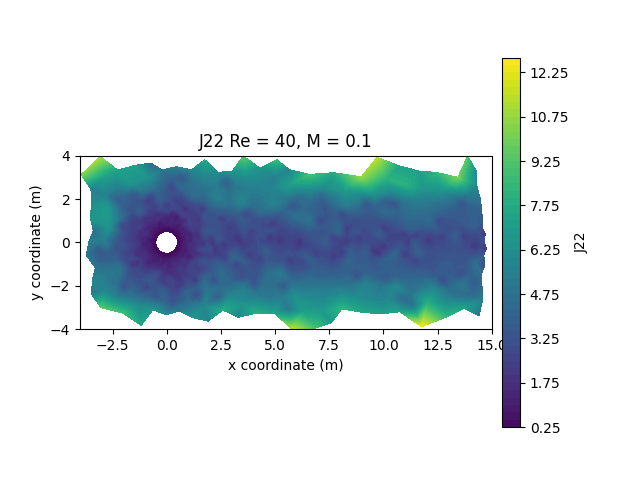

In [6]:
# Plot that shows

fig, ax = plt.subplots()

J_row = 2 # denote the row of the jacobian matrix J_row_col
J_col = 2 # denote the column of jacobian matrix J_row_col

i = J_row - 1 
j = J_col - 1 

# define scalar to plot
data = J[:,i,j][side_nodes]

data_min = data.min()
data_max = data.max()

data_scaled = (data - data_min) / (data_max - data_min)

contour = ax.tricontourf(tri,data[node_filter], levels = 51, vmin = 0)

fig.colorbar(contour, ax=ax, pad=0.02, label= f"J{J_row}{J_col}")
ax.set_title(f"J{J_row}{J_col} Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.set_aspect('equal', 'box') # forcing the scale of x and y axis to equal
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.savefig(f"J{J_row}{J_col}.png")

In [7]:
# def plot_jacobian_component(J, tri, side_nodes, node_filter,
                            J_row, J_col,
                            x_lower, x_upper, y_lower, y_upper):

    i, j = J_row - 1, J_col - 1
    data = J[:, i, j][side_nodes]

    # scale safely to [0, 1]
    dmin, dmax = data.min(), data.max()
    data_scaled = (data - dmin) / (dmax - dmin) if dmax > dmin else np.zeros_like(data)

    fig, ax = plt.subplots()

    contour = ax.tricontourf(
        tri,
        data_scaled[node_filter],
        levels=51,
        cmap="viridis"
    )

    fig.colorbar(contour, ax=ax, pad=0.02, label=f"J{J_row}{J_col}")

    ax.set(
        title=f"J{J_row}{J_col}  Re = 40, M = 0.1",
        xlabel="x coordinate (m)",
        ylabel="y coordinate (m)",
        xlim=(x_lower, x_upper),
        ylim=(y_lower, y_upper)
    )
    ax.set_aspect("equal", "box")

    fig.savefig(
        f"J{J_row}{J_col}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig)

IndentationError: unindent does not match any outer indentation level (<string>, line 5)

In [ ]:
# plot all 25 terms in the jacobian matrix
# for J_row in range(1, 6):
    for J_col in range(1, 6):
        plot_jacobian_component(
            J, tri, side_nodes, node_filter,
            J_row, J_col,
            x_lower, x_upper, y_lower, y_upper
        )